Group 15 - Use case 3

**Introduction – Autonomous Quote Agents**


---


Insurance companies receive a large number of insurance quote requests every day. Manually analyzing each quote to determine **risk level, pricing, and approval decisions can be time-consuming and inefficient**. This often leads to delays in processing customer requests and missed opportunities for policy conversions.

In this project, we implement an **Autonomous Quote Decision System** that automates the evaluation of insurance quotes using a multi-agent pipeline. The system processes customer and vehicle information from the dataset and performs a series of intelligent decisions through specialized agents.

The proposed system consists of four main agents:

**Risk Profiler Agent** – Evaluates the customer's risk level based on driving behavior, vehicle usage, and other related features.

**Conversion Predictor Agent** – Uses a machine learning model to estimate the probability that a customer will purchase the insurance policy.

**Premium Advisor Agent** – Suggests adjustments to the quoted premium in order to improve the likelihood of customer conversion.

**Decision Router Agent** – Generates the final action such as auto approval, agent follow-up, or escalation to a human underwriter.

The system uses a dataset containing insurance quote information such as driver details, vehicle usage, coverage type, salary range, and quoted premium. By applying machine learning techniques and rule-based logic, the system automates the decision-making pipeline and provides faster, data-driven quote evaluation.

The objective of this project is to **demonstrate how autonomous agents combined with machine learning** can improve efficiency in insurance quote processing and support better business decisions.

In [2]:
!pip install pandas scikit-learn shap streamlit imbalanced-learn

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [4]:
df = pd.read_csv("Autonomous QUOTE AGENTS.csv")
df.head()

,Quote_Num,Agent_Type,Q_Creation_DT,Q_Valid_DT,Policy_Bind_DT,Region,Agent_Num,Policy_Type,HH_Vehicles,HH_Drivers,...,Marital_Status,Education,Sal_Range,Coverage,Veh_Usage,Annual_Miles_Range,Vehicl_Cost_Range,Re_Quote,Quoted_Premium,Policy_Bind
0,AQ-C-139212,EA,2020/04/25,2020/06/23,2020/05/23,C,2156,Car,3,3,...,Widow,High School,> $ 25 K <= $ 40 K,Balanced,Commute,> 55 K,> $ 10 K <= $ 20 K,No,693.86,Yes
1,AQ-F-136117,EA,2020/02/21,2020/04/20,NaN,F,2153,Van,2,2,...,Dirvorced,Ph.D,> $ 40 K <= $ 60 K,Balanced,Pleasure,> 7.5 K & <= 15 K,<= $ 10 K,No,635.96,No
2,AQ-F-126801,EA,2020/06/19,2020/08/17,2020/07/12,F,2056,Truck,2,1,...,Dirvorced,Ph.D,> $ 40 K <= $ 60 K,Basic,Commute,> 35 K & <= 45 K,> $ 10 K <= $ 20 K,No,780.64,Yes
3,AQ-E-143467,EA,2020/05/02,2020/06/30,2020/05/24,E,2138,Car,1,2,...,Married,Ph.D,> $ 90 K,Basic,Pleasure,<= 7.5 K,<= $ 10 K,No,723.15,Yes
4,AQ-C-143827,EA,2020/02/12,2020/04/11,2020/02/25,C,2327,Truck,3,1,...,Widow,High School,<= $ 25 K,Basic,Pleasure,> 35 K & <= 45 K,<= $ 10 K,No,738.14,Yes


In [5]:
df = df.drop([
"Quote_Number",
"Customer_ID",
"Q_Creation_DT",
"Q_Valid_DT",
"Policy_Bind_DT"
], axis=1, errors="ignore")

In [6]:
df = df.fillna(method="ffill")

/tmp/ipykernel_2937/567689999.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [7]:
encoder = LabelEncoder()
columns = [
"Agent_Type",
"Region",
"Policy_Type",
"Education",
"Sal_Range",
"Coverage",
"Veh_Usage",
"Annual_Miles_Range",
"Vehicl_Cost_Range"
]
for col in columns:
    df[col] = encoder.fit_transform(df[col])

In [8]:
df["Policy_Bind"] = df["Policy_Bind"].map({"Yes":1, "No":0})

In [9]:
print(df["Policy_Bind"].value_counts())

Policy_Bind
0    113757
1     32502
Name: count, dtype: int64


In [10]:
X = df.drop("Policy_Bind", axis=1)
y = df["Policy_Bind"]

In [11]:
print(y.value_counts())

Policy_Bind
0    113757
1     32502
Name: count, dtype: int64


In [12]:
smote = SMOTE(random_state=42)


categorical_cols_in_X = X.select_dtypes(include='object').columns


for col in categorical_cols_in_X:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])


if np.unique(y).size <= 1:
    print(f"Warning: The target variable 'y' has only {np.unique(y).size} class(es). SMOTE cannot be applied.")
    print("This indicates that after preprocessing, only one type of policy bind status remains. Review previous data cleaning steps (e.g., `dropna()`) if you expected both 'Yes' and 'No' outcomes.")
    X_resampled = X
    y_resampled = y
else:
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print("SMOTE applied successfully.")

SMOTE applied successfully.


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [14]:
def create_risk(row):

    if row["Prev_Accidents"] > 2:
        return 2

    elif row["Prev_Accidents"] > 0:
        return 1

    else:
        return 0

df["Risk_Tier"] = df.apply(create_risk, axis=1)

In [15]:
risk_features = [
"Prev_Accidents",
"Prev_Citations",
"Driving_Exp",
"Driver_Age",
"Veh_Usage",
"Annual_Miles_Range"
]

X_risk = df[risk_features]
y_risk = df["Risk_Tier"]

risk_model = RandomForestClassifier()

risk_model.fit(X_risk, y_risk)

RandomForestClassifier()

In [16]:
conversion_model = RandomForestClassifier(class_weight="balanced")

conversion_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

In [17]:
pred = conversion_model.predict(X_test)

accuracy = accuracy_score(y_test, pred)

print("Model Accuracy:", accuracy)

print(classification_report(y_test, pred))

Model Accuracy: 0.7756191899435202
              precision    recall  f1-score   support

           0       0.73      0.86      0.79     22608
           1       0.83      0.69      0.76     22895

    accuracy                           0.78     45503
   macro avg       0.78      0.78      0.77     45503
weighted avg       0.78      0.78      0.77     45503



In [18]:
def premium_advisor(row):

    premium = row["Quoted_Premium"]

    if premium > 1500:
        return "Reduce Premium"

    elif premium < 500:
        return "Premium OK"

    else:
        return "Consider Discount"

In [19]:
def decision_router(risk, conversion_prob):

    if conversion_prob > 0.75 and risk == 0:
        return "Auto Approve"

    elif conversion_prob > 0.4:
        return "Agent Follow-up"

    else:
        return "Escalate to Underwriter"

In [20]:
def agent_pipeline(sample):


    risk = risk_model.predict(sample[risk_features])[0]


    conversion_prob = conversion_model.predict_proba(sample)[0][1]


    premium_flag = premium_advisor(sample.iloc[0])


    decision = decision_router(risk, conversion_prob)

    return {
        "Risk Tier": risk,
        "Conversion Probability": conversion_prob,
        "Premium Advice": premium_flag,
        "Final Decision": decision
    }

In [21]:
sample = X_test.iloc[[0]]

result = agent_pipeline(sample)

print(result)

{'Risk Tier': np.int64(0), 'Conversion Probability': np.float64(0.48), 'Premium Advice': 'Consider Discount', 'Final Decision': 'Agent Follow-up'}


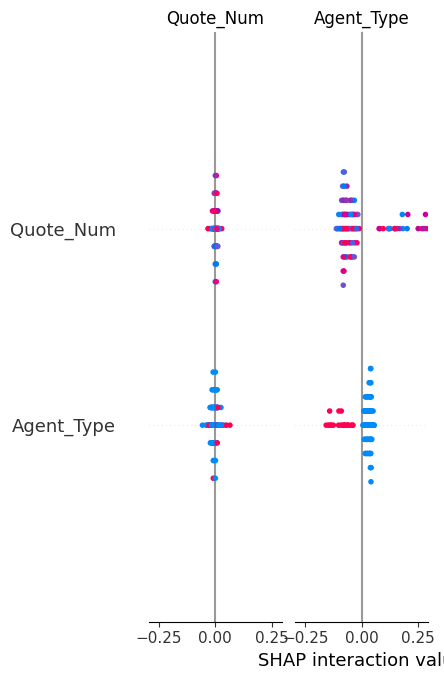

In [22]:
import shap

explainer = shap.TreeExplainer(conversion_model)

X_sample = X_test.sample(100)

shap_values = explainer.shap_values(X_sample)

shap.summary_plot(shap_values, X_sample)